# Investigate Matérn

Example-session choice raster by belief-dim partition, extracted from cell 9 of
[`20260623_investigate_subselection_autocorr_feasibility.ipynb`](20260623_investigate_subselection_autocorr_feasibility.ipynb).

Same figure as the source, but restricted to the **`In X Dim`** and **`Not in X Dim`** conditions.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import utils.behavioral_utils as behavioral_utils
from matplotlib import pyplot as plt
import seaborn as sns
from constants.behavioral_constants import *
from constants.decoding_constants import *
import warnings
warnings.filterwarnings("ignore")

PARTITIONS = ["In X Dim", "Not in X Dim"]

## Example session: choice raster by belief-dim partition

Load one feature/session's behavior, label choices and the belief-dim partition, and plot the
`Chose` / `Not Chose` raster over `TrialNumber` for `In X Dim` and `Not in X Dim`.

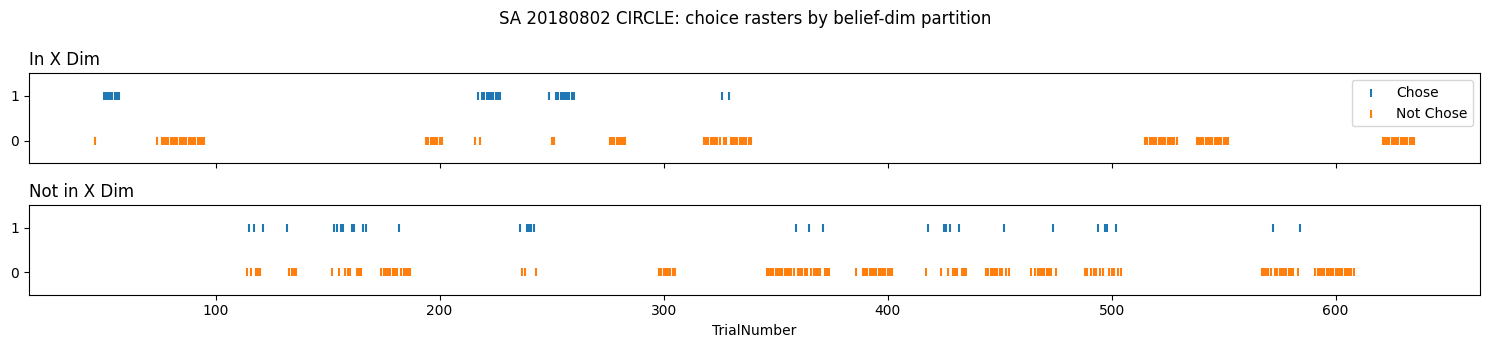

In [2]:
ex_sub, ex_sess, ex_feat = "SA", "20180802", "CIRCLE"
beh = behavioral_utils.get_valid_belief_beh_for_sub_sess(ex_sub, ex_sess)
beh = behavioral_utils.get_feat_choice_label(beh, ex_feat)
beh = behavioral_utils.get_belief_dim_partition(beh, ex_feat, use_x=True)
beh_v = beh[beh.TrialNumber < beh.TrialNumber.min() + 600]

fig, axs = plt.subplots(len(PARTITIONS), 1, figsize=(15, 3.5), sharex=True)
for ax, part in zip(axs, PARTITIONS):
    sub_p = beh_v[beh_v.BeliefDimPartition == part]
    chose = sub_p[sub_p.Choice == "Chose"]
    notc = sub_p[sub_p.Choice == "Not Chose"]
    ax.scatter(chose.TrialNumber, [1] * len(chose), marker="|", label="Chose")
    ax.scatter(notc.TrialNumber, [0] * len(notc), marker="|", label="Not Chose")
    ax.set_title(f"{part}", loc="left"); ax.set_yticks([0, 1]); ax.set_ylim(-0.5, 1.5)
axs[0].legend(loc="upper right"); axs[-1].set_xlabel("TrialNumber")
fig.suptitle(f"{ex_sub} {ex_sess} {ex_feat}: choice rasters by belief-dim partition")
plt.tight_layout(); plt.show()

## Pairwise trial-number distances per condition

For each of the four conditions (`In X Dim` / `Not in X Dim` × `Chose` / `Not Chose`), take the
`TrialNumber`s that satisfy it, compute all pairwise distances, and plot a histogram. All four panels
share the same x-axis and bin size.

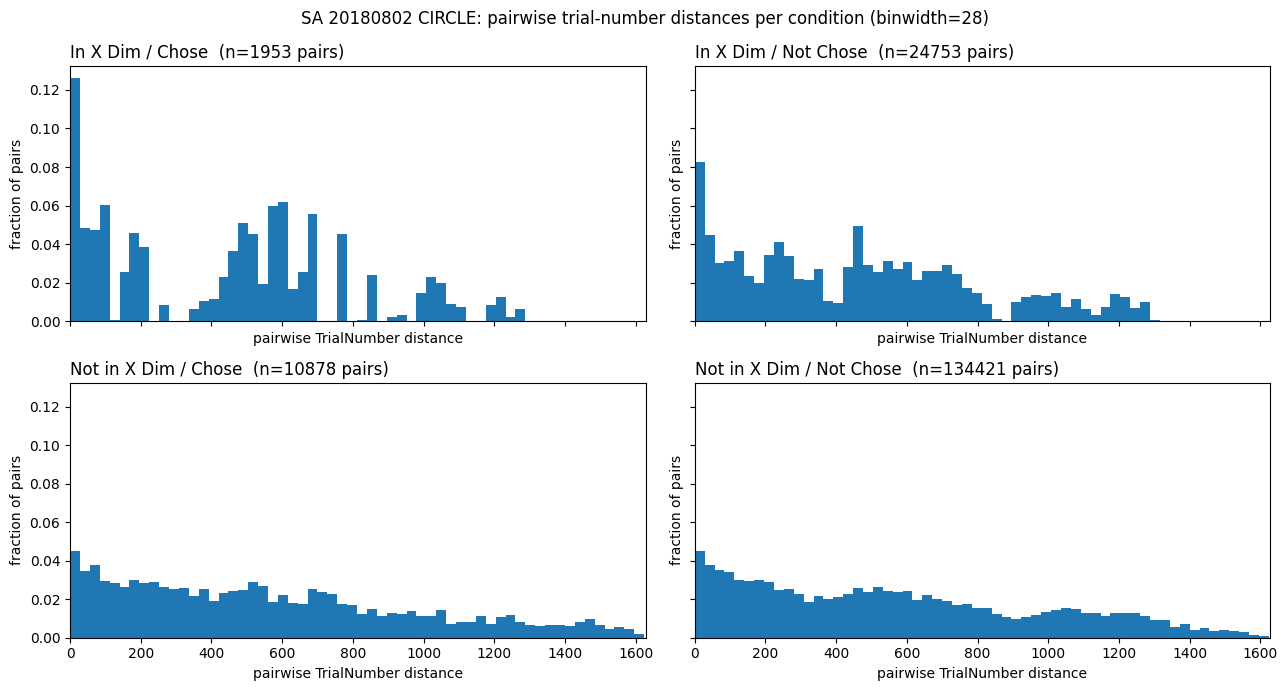

In [3]:
conditions = [(p, c) for p in PARTITIONS for c in ["Chose", "Not Chose"]]

def pairwise_dists(tn):
    tn = np.sort(np.asarray(tn))
    d = np.abs(np.subtract.outer(tn, tn))
    iu = np.triu_indices(len(tn), k=1)
    return d[iu]

dists = {}
for p, c in conditions:
    tn = beh[(beh.BeliefDimPartition == p) & (beh.Choice == c)].TrialNumber.values
    dists[(p, c)] = pairwise_dists(tn)

# shared x-axis and bin size across all conditions
gmax = max(d.max() for d in dists.values() if len(d))
binwidth = max(1, int(np.ceil(gmax / 60)))   # ~60 bins, common to every panel
bins = np.arange(0, gmax + binwidth, binwidth)

fig, axs = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
for ax, (p, c) in zip(axs.ravel(), conditions):
    d = dists[(p, c)]
    ax.hist(d, bins=bins, weights=np.ones_like(d, dtype=float) / len(d))  # fractions sum to 1
    ax.set_title(f"{p} / {c}  (n={len(d)} pairs)", loc="left")
    ax.set_xlabel("pairwise TrialNumber distance")
    ax.set_ylabel("fraction of pairs")
    ax.set_xlim(0, gmax)
fig.suptitle(f"{ex_sub} {ex_sess} {ex_feat}: pairwise trial-number distances per condition "
             f"(binwidth={binwidth})")
plt.tight_layout(); plt.show()